In [15]:
import os
import re
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from skimage import exposure, filters, util
from skimage.transform import rotate, AffineTransform, warp
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [16]:
import os
from pathlib import Path

# === PATH KAGGLE (sudah disesuaikan dengan struktur folder kamu) ===
BASE = Path("/kaggle/input/datasets/mhmdrizkisaputra/garpu-uas-dataset")

# Sumber 1: Roboflow (ada di dataset_roboflow/train, valid, test)
ROBOFLOW_DIR = BASE / "dataset_roboflow"

# Sumber 2: Manual download Pinterest (ada di dataset_garpu/gigi 3 & gigi 4)
SCRAPED_DIR = BASE / "dataset_garpu"

# Sumber 3: Skip
USER_PHOTOS_DIR = Path("/kaggle/tidak-ada")

# Output WAJIB di /kaggle/working/
WORK_DIR = Path("/kaggle/working/v3_workspace")
AUG_DIR = WORK_DIR / "augmented"
MODEL_DIR = WORK_DIR / "saved_models"
RESULT_DIR = WORK_DIR / "results"

for d in [WORK_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["gigi 3", "gigi 4"]
CLASS_TO_LABEL = {"gigi 3": 0, "gigi 4": 1}
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TARGET_PER_CLASS_TRAIN = 1000

# Verifikasi
print("=== KONFIGURASI PATH ===")
print(f"ROBOFLOW_DIR : {ROBOFLOW_DIR}")
print(f"  → {'ADA ✅' if ROBOFLOW_DIR.exists() else 'TIDAK ADA ⚠️'}")
print(f"  → train: {'ADA ✅' if (ROBOFLOW_DIR/'train').exists() else 'TIDAK ADA ⚠️'}")
print(f"  → valid: {'ADA ✅' if (ROBOFLOW_DIR/'valid').exists() else 'TIDAK ADA ⚠️'}")
print(f"  → test : {'ADA ✅' if (ROBOFLOW_DIR/'test').exists() else 'TIDAK ADA ⚠️'}")
print()
print(f"SCRAPED_DIR  : {SCRAPED_DIR}")
print(f"  → {'ADA ✅' if SCRAPED_DIR.exists() else 'TIDAK ADA ⚠️'}")
print(f"  → gigi 3: {len(list((SCRAPED_DIR/'gigi 3').glob('*'))) if (SCRAPED_DIR/'gigi 3').exists() else 0} file")
print(f"  → gigi 4: {len(list((SCRAPED_DIR/'gigi 4').glob('*'))) if (SCRAPED_DIR/'gigi 4').exists() else 0} file")
print()
print(f"WORK_DIR     : {WORK_DIR} ✅")

=== KONFIGURASI PATH ===
ROBOFLOW_DIR : /kaggle/input/datasets/mhmdrizkisaputra/garpu-uas-dataset/dataset_roboflow
  → ADA ✅
  → train: ADA ✅
  → valid: ADA ✅
  → test : ADA ✅

SCRAPED_DIR  : /kaggle/input/datasets/mhmdrizkisaputra/garpu-uas-dataset/dataset_garpu
  → ADA ✅
  → gigi 3: 200 file
  → gigi 4: 200 file

WORK_DIR     : /kaggle/working/v3_workspace ✅


In [17]:
def get_image_files(folder):
    if not folder.exists():
        return []
    return [f for f in folder.iterdir() 
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS]

def extract_group_id(filepath, source_prefix=""):
    """File dari foto asli yang sama akan punya group ID sama."""
    name = Path(filepath).stem
    
    # Roboflow pattern: IMG_xxx_xxx_jpg.rf.hash
    match = re.match(r'^(IMG_\d+_\d+)', name)
    if match:
        return f"roboflow_{match.group(1)}"
    
    return f"{source_prefix}_{name}"

def build_df_from_source(base_dir, source_prefix, splits_to_include=None):
    rows = []
    if not base_dir.exists():
        return pd.DataFrame()
    
    if splits_to_include:
        for split in splits_to_include:
            for c in CLASS_NAMES:
                split_dir = base_dir / split / c
                for f in get_image_files(split_dir):
                    rows.append({
                        "filepath": str(f),
                        "label_name": c,
                        "label": CLASS_TO_LABEL[c],
                        "source": source_prefix,
                        "group_id": extract_group_id(f, source_prefix)
                    })
    else:
        for c in CLASS_NAMES:
            for f in get_image_files(base_dir / c):
                rows.append({
                    "filepath": str(f),
                    "label_name": c,
                    "label": CLASS_TO_LABEL[c],
                    "source": source_prefix,
                    "group_id": extract_group_id(f, source_prefix)
                })
    
    return pd.DataFrame(rows)

# Load semua sumber
df_roboflow = build_df_from_source(ROBOFLOW_DIR, "roboflow", ["train", "valid", "test"])
df_scraped = build_df_from_source(SCRAPED_DIR, "scraped")
df_user = build_df_from_source(USER_PHOTOS_DIR, "user")

all_df = pd.concat([df_roboflow, df_scraped, df_user], ignore_index=True)

print(f"=== STATISTIK DATASET ===")
print(f"Roboflow    : {len(df_roboflow):4d} files | {df_roboflow['group_id'].nunique() if len(df_roboflow) > 0 else 0:4d} foto asli unik")
print(f"Manual D/L  : {len(df_scraped):4d} files | {df_scraped['group_id'].nunique() if len(df_scraped) > 0 else 0:4d} foto unik")
print(f"User photos : {len(df_user):4d} files | {df_user['group_id'].nunique() if len(df_user) > 0 else 0:4d} foto unik")
print(f"{'='*50}")
print(f"TOTAL       : {len(all_df):4d} files | {all_df['group_id'].nunique():4d} foto asli unik")
print(f"\nDistribusi per kelas:")
print(all_df.groupby(['label_name', 'source']).size().unstack(fill_value=0))

=== STATISTIK DATASET ===
Roboflow    :  214 files |   89 foto asli unik
Manual D/L  :  400 files |  395 foto unik
User photos :    0 files |    0 foto unik
TOTAL       :  614 files |  484 foto asli unik

Distribusi per kelas:
source      roboflow  scraped
label_name                   
gigi 3           107      200
gigi 4           107      200


In [18]:
# Verifikasi dataset cukup
assert len(all_df) > 0, "Dataset KOSONG! Cek path-path di Section 2."
for c in CLASS_NAMES:
    n = len(all_df[all_df['label_name'] == c])
    assert n >= 50, f"Kelas '{c}' hanya {n} gambar, terlalu sedikit (minimal 50)!"

print("✓ Dataset cukup untuk training")

✓ Dataset cukup untuk training


In [19]:
# Split test (15%) - group aware
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(all_df, all_df['label'], groups=all_df['group_id']))

trainval_df = all_df.iloc[trainval_idx].reset_index(drop=True)
test_df = all_df.iloc[test_idx].reset_index(drop=True)

# Split val (15% dari total ≈ 17.65% dari trainval) - group aware
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
train_idx, val_idx = next(gss2.split(trainval_df, trainval_df['label'], groups=trainval_df['group_id']))

train_df_orig = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

print("=== HASIL GROUP-AWARE SPLIT ===")
for name, df in [("Train", train_df_orig), ("Val", val_df), ("Test", test_df)]:
    n_files = len(df)
    n_groups = df['group_id'].nunique()
    dist = df['label'].value_counts().to_dict()
    print(f"{name:6s}: {n_files:4d} files | {n_groups:4d} groups | Dist: {dist}")

# Verifikasi NO LEAKAGE
train_groups = set(train_df_orig['group_id'])
val_groups = set(val_df['group_id'])
test_groups = set(test_df['group_id'])

print(f"\n=== VERIFIKASI NO LEAKAGE ===")
overlap_tv = len(train_groups & val_groups)
overlap_tt = len(train_groups & test_groups)
overlap_vt = len(val_groups & test_groups)
print(f"Overlap train-val : {overlap_tv}  (harus 0)")
print(f"Overlap train-test: {overlap_tt}  (harus 0)")
print(f"Overlap val-test  : {overlap_vt}  (harus 0)")

if overlap_tv == 0 and overlap_tt == 0 and overlap_vt == 0:
    print(f"\n✓ Tidak ada data leakage!")
else:
    print(f"\n✗ ADA LEAKAGE — periksa group_id extraction!")

=== HASIL GROUP-AWARE SPLIT ===
Train :  415 files |  338 groups | Dist: {1: 211, 0: 204}
Val   :   99 files |   73 groups | Dist: {0: 58, 1: 41}
Test  :  100 files |   73 groups | Dist: {1: 55, 0: 45}

=== VERIFIKASI NO LEAKAGE ===
Overlap train-val : 0  (harus 0)
Overlap train-test: 0  (harus 0)
Overlap val-test  : 0  (harus 0)

✓ Tidak ada data leakage!


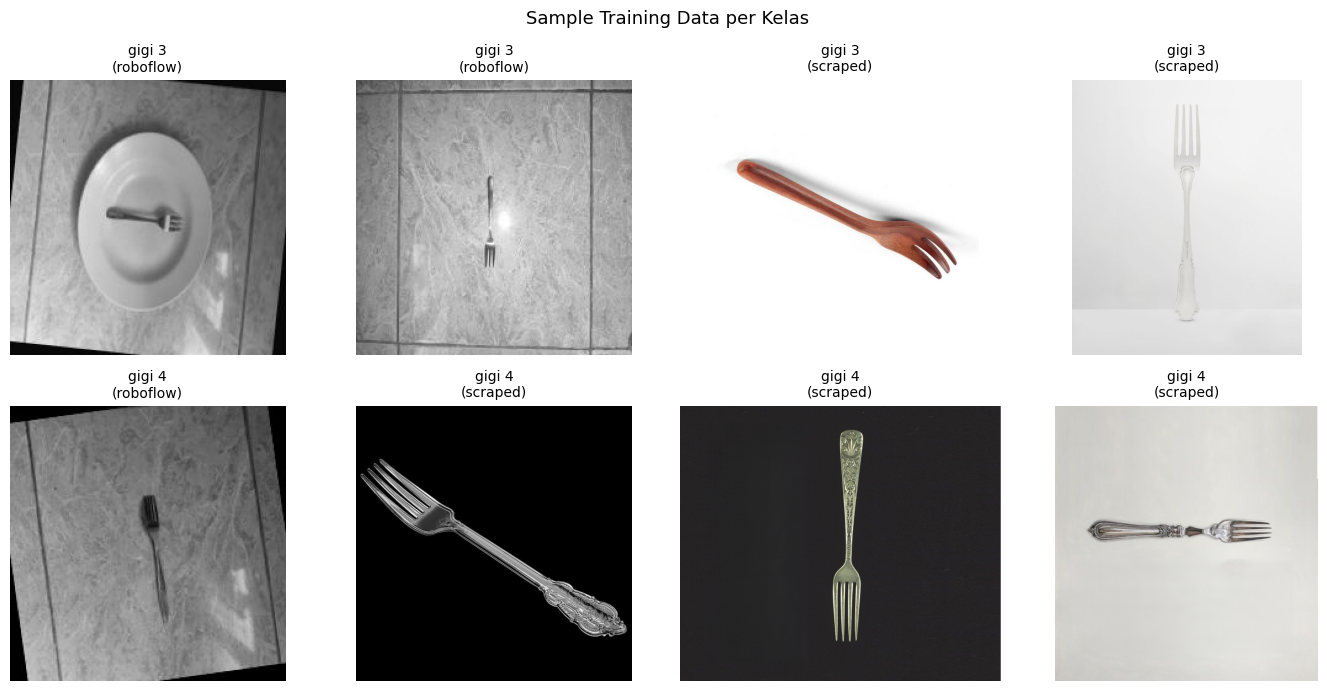

In [20]:
# Visualisasi sampel
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, c in enumerate(CLASS_NAMES):
    class_train = train_df_orig[train_df_orig["label_name"] == c]
    n_sample = min(4, len(class_train))
    sample = class_train.sample(n_sample, random_state=SEED)
    for j, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{c}\n({row['source']})", fontsize=10)
        axes[i, j].axis("off")
plt.suptitle("Sample Training Data per Kelas", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Fungsi augmentasi
def aug_rotate(img):
    return rotate(img, angle=random.uniform(-15, 15), mode="edge", preserve_range=True)

def aug_flip(img):
    return np.fliplr(img)

def aug_brightness(img):
    return exposure.adjust_gamma(img / 255.0, gamma=random.uniform(0.7, 1.3)) * 255

def aug_contrast(img):
    p2, p98 = np.percentile(img, (random.uniform(1, 5), random.uniform(95, 99)))
    return exposure.rescale_intensity(img, in_range=(p2, p98))

def aug_blur(img):
    return filters.gaussian(img / 255.0, sigma=random.uniform(0.3, 1.2), channel_axis=-1) * 255

def aug_shift(img):
    tx, ty = random.uniform(-15, 15), random.uniform(-15, 15)
    return warp(img, AffineTransform(translation=(tx, ty)), mode="edge", preserve_range=True)

def aug_zoom(img):
    scale = random.uniform(0.85, 1.15)
    h, w = img.shape[:2]
    tf_ = AffineTransform(scale=(scale, scale), translation=(w*(1-scale)/2, h*(1-scale)/2))
    return warp(img, tf_.inverse, mode="edge", preserve_range=True)

def aug_noise(img):
    return util.random_noise(img / 255.0, mode='gaussian', var=0.001) * 255

def random_augment(img):
    augs = [aug_rotate, aug_flip, aug_brightness, aug_contrast, aug_blur, aug_shift, aug_zoom, aug_noise]
    selected = random.sample(augs, random.choice([1, 2]))
    out = img.copy().astype(np.float32)
    for fn in selected:
        out = fn(out)
    return np.clip(out, 0, 255).astype(np.uint8)

In [22]:
# Setup folder augmented
if AUG_DIR.exists():
    shutil.rmtree(AUG_DIR)
for split in ["train", "val", "test"]:
    for c in CLASS_NAMES:
        (AUG_DIR / split / c).mkdir(parents=True, exist_ok=True)

# Simpan val & test (TANPA augmentasi)
print("Menyimpan val set...")
for i, row in val_df.iterrows():
    img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
    out_path = AUG_DIR / "val" / row["label_name"] / f"val_{i:05d}.jpg"
    img.save(out_path, quality=95)

print("Menyimpan test set...")
for i, row in test_df.iterrows():
    img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
    out_path = AUG_DIR / "test" / row["label_name"] / f"test_{i:05d}.jpg"
    img.save(out_path, quality=95)

print(f"\n✓ Val tersimpan : {len(val_df)}")
print(f"✓ Test tersimpan: {len(test_df)}")

Menyimpan val set...
Menyimpan test set...

✓ Val tersimpan : 99
✓ Test tersimpan: 100


In [23]:
# Augmentasi train ke 1000 per kelas
print(f"Target: {TARGET_PER_CLASS_TRAIN} per kelas\n")

for class_name in CLASS_NAMES:
    print(f"--- Kelas: {class_name} ---")
    class_train = train_df_orig[train_df_orig["label_name"] == class_name].reset_index(drop=True)
    print(f"Original train: {len(class_train)} gambar")
    
    out_dir = AUG_DIR / "train" / class_name
    
    # Simpan original
    for i, row in class_train.iterrows():
        img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
        img.save(out_dir / f"orig_{i:05d}.jpg", quality=95)
    
    # Generate augmented
    needed = TARGET_PER_CLASS_TRAIN - len(class_train)
    if needed <= 0:
        print(f"Sudah {len(class_train)} >= target, skip augmentation")
        continue
    
    print(f"Generating {needed} augmented...")
    aug_count = 0
    while aug_count < needed:
        row = class_train.sample(1).iloc[0]
        img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
        aug_array = random_augment(np.array(img))
        Image.fromarray(aug_array).save(out_dir / f"aug_{aug_count:05d}.jpg", quality=92)
        aug_count += 1
        if aug_count % 200 == 0:
            print(f"  Progress: {aug_count}/{needed}")
    
    total = len(list(out_dir.glob("*.jpg")))
    print(f"Total di {class_name}: {total}\n")

Target: 1000 per kelas

--- Kelas: gigi 3 ---
Original train: 204 gambar
Generating 796 augmented...
  Progress: 200/796
  Progress: 400/796
  Progress: 600/796
Total di gigi 3: 1000

--- Kelas: gigi 4 ---
Original train: 211 gambar
Generating 789 augmented...
  Progress: 200/789
  Progress: 400/789
  Progress: 600/789
Total di gigi 4: 1000



In [24]:
# Verifikasi distribusi final
print("=== DISTRIBUSI DATASET FINAL ===")
total_all = 0
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}:")
    split_total = 0
    for c in CLASS_NAMES:
        n = len(list((AUG_DIR / split / c).glob("*.jpg")))
        print(f"  {c}: {n}")
        split_total += n
    print(f"  TOTAL {split}: {split_total}")
    total_all += split_total

print(f"\n{'='*50}")
print(f"GRAND TOTAL: {total_all} gambar")
print(f"{'='*50}")

=== DISTRIBUSI DATASET FINAL ===

TRAIN:
  gigi 3: 1000
  gigi 4: 1000
  TOTAL train: 2000

VAL:
  gigi 3: 58
  gigi 4: 41
  TOTAL val: 99

TEST:
  gigi 3: 45
  gigi 4: 55
  TOTAL test: 100

GRAND TOTAL: 2199 gambar


In [25]:
def build_df_from_folder(folder):
    rows = []
    for c in CLASS_NAMES:
        for f in (folder / c).glob("*.jpg"):
            rows.append({"filepath": str(f), "label_name": c, "label": CLASS_TO_LABEL[c]})
    return pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = build_df_from_folder(AUG_DIR / "train")
val_df_aug = build_df_from_folder(AUG_DIR / "val")
test_df_aug = build_df_from_folder(AUG_DIR / "test")

HOG_PARAMS = {"orientations": 6, "pixels_per_cell": (16, 16), "cells_per_block": (2, 2)}

def extract_hog_features(filepath):
    img = np.array(Image.open(filepath).convert("L").resize(IMG_SIZE))
    return hog(img, **HOG_PARAMS, block_norm='L2-Hys', feature_vector=True)

print("Extracting HOG features (mungkin 1-2 menit)...")
X_train = np.array([extract_hog_features(p) for p in train_df["filepath"]])
y_train = train_df["label"].values
X_test = np.array([extract_hog_features(p) for p in test_df_aug["filepath"]])
y_test = test_df_aug["label"].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Extracting HOG features (mungkin 1-2 menit)...
X_train: (2000, 4056)
X_test:  (100, 4056)


In [26]:
# Hyperparameter Tuning dengan GridSearchCV (Bonus #3)
print("Grid Search SVM (~5-10 menit)...")
param_grid = {"clf__kernel": ["linear", "rbf"], "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=SEED, probability=True))])
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print(f"\nBest params: {grid.best_params_}")
print(f"Best CV F1 : {grid.best_score_:.4f}")

Grid Search SVM (~5-10 menit)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'clf__C': 100, 'clf__kernel': 'rbf'}
Best CV F1 : 0.8329


In [27]:
# Train 4 varian SVM
ml_results = {}

print("Training SVM-Linear...")
svm_linear = Pipeline([("scaler", StandardScaler()),
                       ("clf", SVC(kernel="linear", C=0.01, probability=True, random_state=SEED))])
svm_linear.fit(X_train, y_train)
ml_results["SVM-Linear"] = svm_linear

print("Training SVM-RBF...")
svm_rbf = Pipeline([("scaler", StandardScaler()),
                    ("clf", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED))])
svm_rbf.fit(X_train, y_train)
ml_results["SVM-RBF"] = svm_rbf

print("Training SVM-PCA...")
svm_pca = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=0.95)),
                    ("clf", SVC(kernel="linear", C=0.001, probability=True, random_state=SEED))])
svm_pca.fit(X_train, y_train)
ml_results["SVM-PCA"] = svm_pca

ml_results["SVM-Best-Grid"] = grid.best_estimator_
print(f"\nTotal ML models: {len(ml_results)}")

Training SVM-Linear...
Training SVM-RBF...
Training SVM-PCA...

Total ML models: 4


In [28]:
# Generator untuk MobileNetV2 & CNN Baseline (PAKAI rescale 1/255)
train_gen = ImageDataGenerator(rescale=1./255, rotation_range=10,
                                width_shift_range=0.1, height_shift_range=0.1,
                                horizontal_flip=True, fill_mode='nearest')
val_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_directory(AUG_DIR/"train", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=True, seed=SEED)
val_flow = val_gen.flow_from_directory(AUG_DIR/"val", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=False)
test_flow = val_gen.flow_from_directory(AUG_DIR/"test", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=False)

# Generator KHUSUS EfficientNet (TANPA rescale - pixel raw 0-255)
train_gen_eff = ImageDataGenerator(rotation_range=10, width_shift_range=0.1,
                                    height_shift_range=0.1, horizontal_flip=True, fill_mode='nearest')
val_gen_eff = ImageDataGenerator()

train_flow_eff = train_gen_eff.flow_from_directory(AUG_DIR/"train", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=True, seed=SEED)
val_flow_eff = val_gen_eff.flow_from_directory(AUG_DIR/"val", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=False)
test_flow_eff = val_gen_eff.flow_from_directory(AUG_DIR/"test", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', classes=CLASS_NAMES, shuffle=False)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

Found 2000 images belonging to 2 classes.
Found 99 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 99 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [29]:
# MODEL: CNN Baseline (from scratch)
cnn_baseline = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(), layers.Dropout(0.3),
    layers.Dense(64, activation='relu'), layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
cnn_baseline.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
print("Training CNN Baseline...")
hist_cnn = cnn_baseline.fit(train_flow, validation_data=val_flow, epochs=25,
                             callbacks=[early_stop, reduce_lr], verbose=1)
cnn_baseline.save(MODEL_DIR / "cnn_baseline.keras")

I0000 00:00:1781462055.031865      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781462055.037945      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training CNN Baseline...
Epoch 1/25


I0000 00:00:1781462058.319555     233 service.cc:152] XLA service 0x7c4a04085e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781462058.319601     233 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781462058.319608     233 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781462058.745477     233 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/125 ━━━━━━━━━━━━━━━━━━━━ 12:33 6s/step - accuracy: 0.8125 - loss: 0.6637

I0000 00:00:1781462062.669441     233 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 174ms/step - accuracy: 0.5115 - loss: 0.6947 - val_accuracy: 0.5657 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.5540 - loss: 0.6885 - val_accuracy: 0.4242 - val_loss: 0.7123 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.5650 - loss: 0.6768 - val_accuracy: 0.5758 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.5535 - loss: 0.6820 - val_accuracy: 0.5253 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.5905 - loss: 0.6543 - val_accuracy: 0.5152 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.5790 - loss: 0.6482 - val_accuracy: 0.5253 - val_loss: 0.7244 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.5940 - loss:

In [30]:
# MODEL: MobileNetV2 (Transfer Learning)
mn_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
mn_base.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = mn_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
mobilenet = models.Model(inputs, outputs)
mobilenet.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

print("Phase 1: Train top layers (frozen base)...")
hist_mn1 = mobilenet.fit(train_flow, validation_data=val_flow, epochs=15,
                          callbacks=[early_stop, reduce_lr], verbose=1)

print("\nPhase 2: Fine-tuning...")
mn_base.trainable = True
for layer in mn_base.layers[:100]:
    layer.trainable = False
mobilenet.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
hist_mn2 = mobilenet.fit(train_flow, validation_data=val_flow, epochs=10,
                          callbacks=[early_stop, reduce_lr], verbose=1)
mobilenet.save(MODEL_DIR / "mobilenetv2.keras")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Train top layers (frozen base)...
Epoch 1/15


2026-06-14 18:38:19.998555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:38:20.136378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:38:20.272742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6633 - loss: 0.6248

2026-06-14 18:38:54.215121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:38:54.372368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:38:54.508648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 271ms/step - accuracy: 0.7365 - loss: 0.5239 - val_accuracy: 0.8384 - val_loss: 0.3551 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.8225 - loss: 0.3781 - val_accuracy: 0.8485 - val_loss: 0.3230 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.8410 - loss: 0.3205 - val_accuracy: 0.8687 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8610 - loss: 0.2833 - val_accuracy: 0.8586 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8685 - loss: 0.2597 - val_accuracy: 0.8889 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.8715 - loss: 0.2537 - val_accuracy: 0.8586 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8695 - loss:

In [31]:
# MODEL: EfficientNetB0 (Transfer Learning)
# PENTING: pakai train_flow_eff (TANPA rescale)
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
eff_base.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = eff_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
efficientnet = models.Model(inputs, outputs)
efficientnet.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

print("Training EfficientNetB0 (pixel raw 0-255)...")
hist_eff = efficientnet.fit(train_flow_eff, validation_data=val_flow_eff, epochs=20,
                             callbacks=[early_stop, reduce_lr], verbose=1)
efficientnet.save(MODEL_DIR / "efficientnetb0.keras")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training EfficientNetB0 (pixel raw 0-255)...
Epoch 1/20


2026-06-14 18:47:40.037488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:47:40.177887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:47:40.508458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:47:40.655948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:47:40.796330: E external/local_xla/xla/stream_

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6881 - loss: 0.5545

2026-06-14 18:48:16.550910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:48:16.685838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:48:16.986715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:48:17.127383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:48:17.903099: E external/local_xla/xla/stream_

125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 270ms/step - accuracy: 0.7415 - loss: 0.4821 - val_accuracy: 0.8889 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.8350 - loss: 0.3448 - val_accuracy: 0.9091 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.8420 - loss: 0.3056 - val_accuracy: 0.9293 - val_loss: 0.2215 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.8655 - loss: 0.2681 - val_accuracy: 0.9495 - val_loss: 0.1667 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.8515 - loss: 0.2636 - val_accuracy: 0.9394 - val_loss: 0.1522 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.8650 - loss: 0.2441 - val_accuracy: 0.8889 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8725 - loss:

In [32]:
def evaluate_ml(name, model, X, y):
    y_pred = model.predict(X)
    return {"Model": name, "Type": "ML",
            "Accuracy": accuracy_score(y, y_pred),
            "Precision": precision_score(y, y_pred, average='macro', zero_division=0),
            "Recall": recall_score(y, y_pred, average='macro', zero_division=0),
            "F1-Score": f1_score(y, y_pred, average='macro', zero_division=0),
            "y_true": y, "y_pred": y_pred}

def evaluate_dl(name, model, flow):
    flow.reset()
    y_true = flow.classes
    y_prob = model.predict(flow, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    return {"Model": name, "Type": "DL",
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
            "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

all_results = []
for name, model in ml_results.items():
    res = evaluate_ml(name, model, X_test, y_test)
    all_results.append(res)

all_results.append(evaluate_dl("CNN-Baseline", cnn_baseline, test_flow))
all_results.append(evaluate_dl("MobileNetV2", mobilenet, test_flow))
all_results.append(evaluate_dl("EfficientNetB0", efficientnet, test_flow_eff))  # PAKAI test_flow_eff

print("=== HASIL EVALUASI ===")
for r in all_results:
    print(f"{r['Model']:20s} | Acc={r['Accuracy']:.4f} | F1={r['F1-Score']:.4f}")

2026-06-14 18:54:50.885719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:54:51.023920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:54:51.160132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-06-14 18:55:04.810769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:55:04.945880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:55:05.249077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:55:05.389800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:55:06.147279: E external/local_xla/xla/stream_

=== HASIL EVALUASI ===
SVM-Linear           | Acc=0.6300 | F1=0.6300
SVM-RBF              | Acc=0.5800 | F1=0.5785
SVM-PCA              | Acc=0.5300 | F1=0.5296
SVM-Best-Grid        | Acc=0.5900 | F1=0.5880
CNN-Baseline         | Acc=0.4600 | F1=0.3443
MobileNetV2          | Acc=0.8100 | F1=0.8100
EfficientNetB0       | Acc=0.9000 | F1=0.8974


In [33]:
# Tabel perbandingan
keep_cols = ["Model", "Type", "Accuracy", "Precision", "Recall", "F1-Score"]
comparison_df = pd.DataFrame([{k: r[k] for k in keep_cols} for r in all_results])
comparison_df = comparison_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
comparison_df["Keterangan"] = ""
comparison_df.loc[0, "Keterangan"] = "Best Model"

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison_df[col] = comparison_df[col].round(4)

display(comparison_df)
comparison_df.to_csv(RESULT_DIR / "comparison_all_models.csv", index=False)
print(f"\nTersimpan: {RESULT_DIR / 'comparison_all_models.csv'}")

,Model,Type,Accuracy,Precision,Recall,F1-Score,Keterangan
0,EfficientNetB0,DL,0.90,0.9088,0.8929,0.8974,Best Model
1,MobileNetV2,DL,0.81,0.8206,0.8192,0.8100,
2,SVM-Linear,ML,0.63,0.6349,0.6354,0.6300,
3,SVM-Best-Grid,ML,0.59,0.5881,0.5889,0.5880,
4,SVM-RBF,ML,0.58,0.5790,0.5798,0.5785,
5,SVM-PCA,ML,0.53,0.5321,0.5323,0.5296,
6,CNN-Baseline,DL,0.46,0.5601,0.5071,0.3443,



Tersimpan: /kaggle/working/v3_workspace/results/comparison_all_models.csv


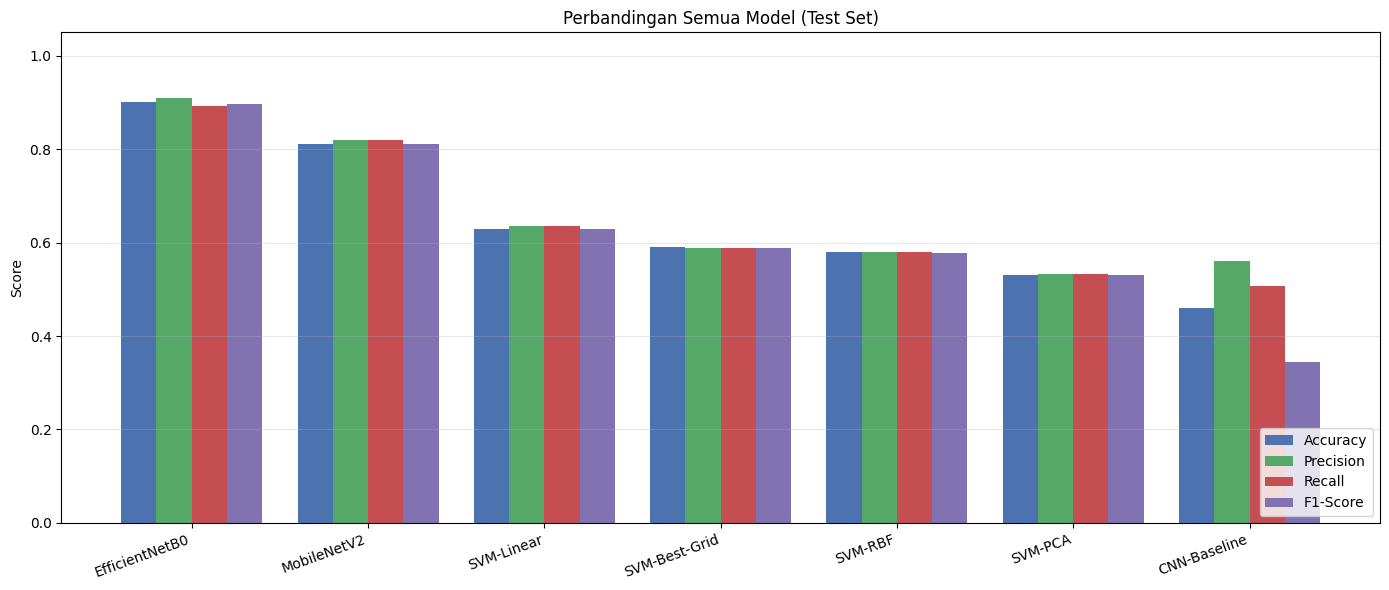

In [34]:
# Bar chart perbandingan
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comparison_df))
width = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, m in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[m], width, label=m, color=colors[i])

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(comparison_df["Model"], rotation=20, ha='right')
ax.set_ylabel("Score")
ax.set_title("Perbandingan Semua Model (Test Set)")
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "comparison_chart.png", dpi=200, bbox_inches='tight')
plt.show()

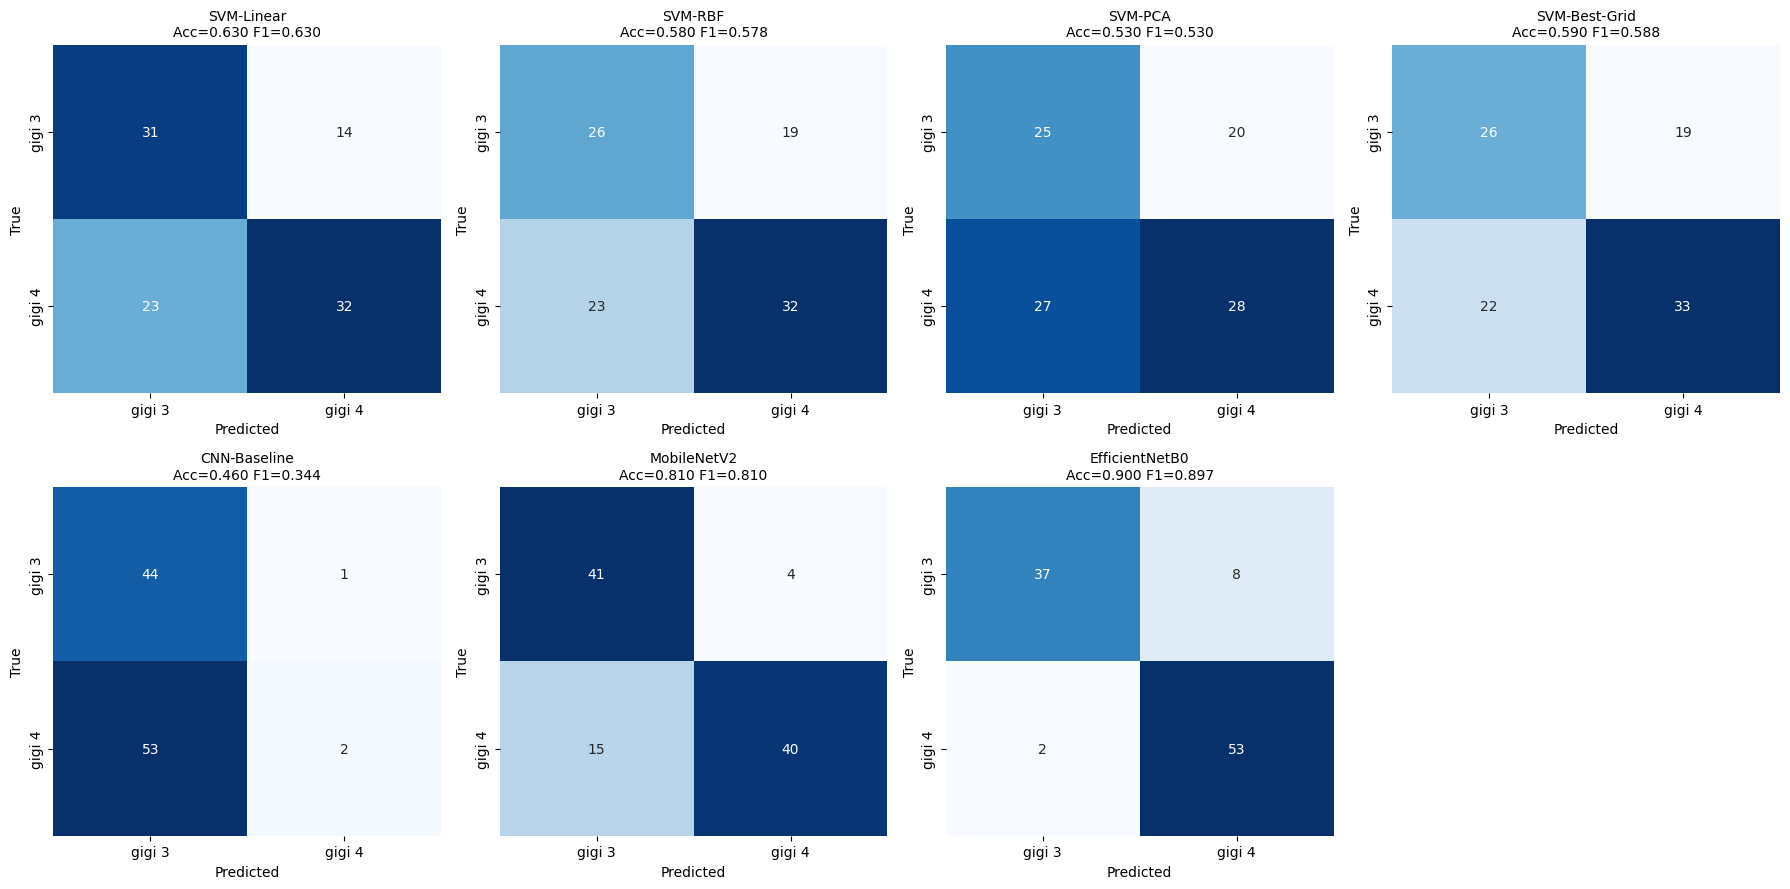

In [35]:
# Confusion matrices semua model
n = len(all_results)
rows = (n + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(18, 4.5*rows))
axes = axes.flatten() if n > 1 else [axes]

for i, res in enumerate(all_results):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[i], cbar=False)
    axes[i].set_title(f"{res['Model']}\nAcc={res['Accuracy']:.3f} F1={res['F1-Score']:.3f}", fontsize=10)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrices_all.png", dpi=200, bbox_inches='tight')
plt.show()

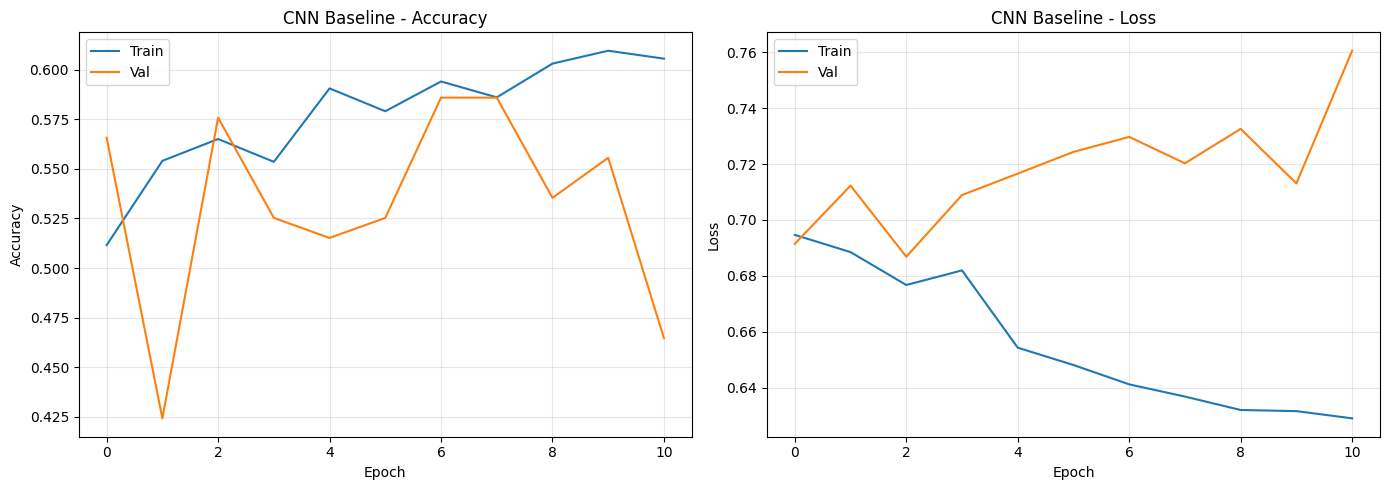

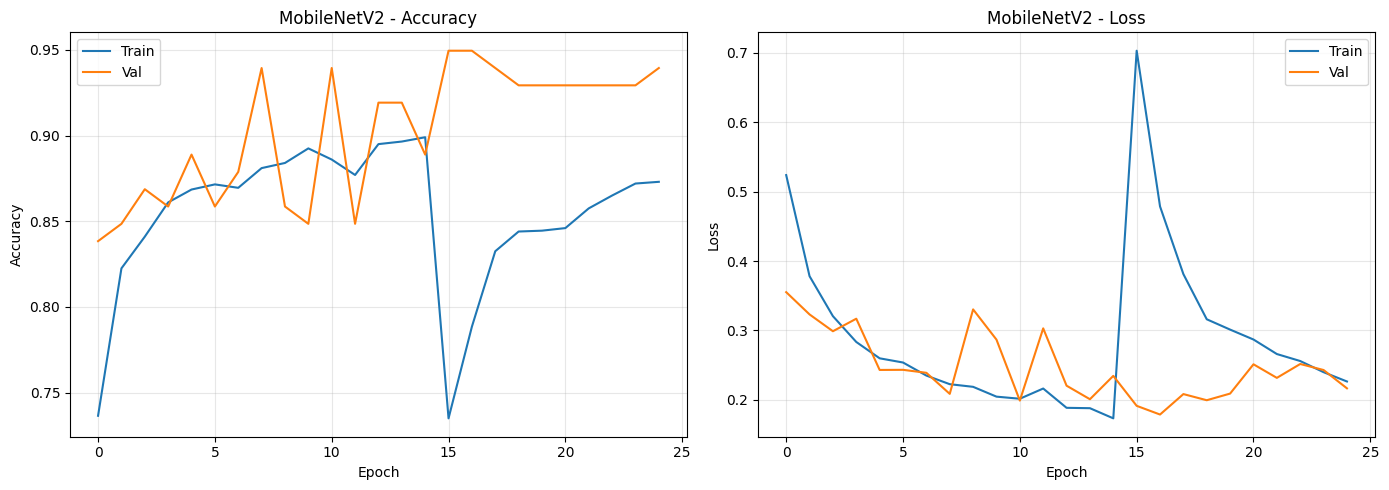

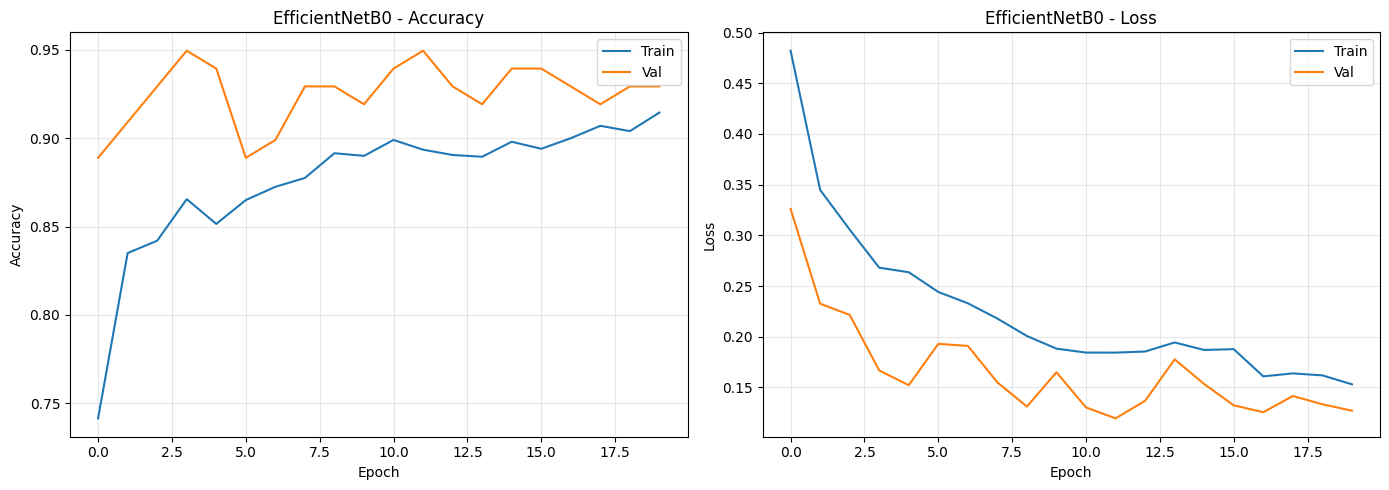

In [36]:
# Training history DL models
def plot_history(hist_list, title, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in hist_list:
        acc.extend(h.history['accuracy'])
        val_acc.extend(h.history['val_accuracy'])
        loss.extend(h.history['loss'])
        val_loss.extend(h.history['val_loss'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(acc, label='Train'); ax1.plot(val_acc, label='Val')
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.set_title(f"{title} - Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(loss, label='Train'); ax2.plot(val_loss, label='Val')
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title(f"{title} - Loss"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

plot_history([hist_cnn], "CNN Baseline", RESULT_DIR / "history_cnn.png")
plot_history([hist_mn1, hist_mn2], "MobileNetV2", RESULT_DIR / "history_mobilenet.png")
plot_history([hist_eff], "EfficientNetB0", RESULT_DIR / "history_efficientnet.png")

In [37]:
# Classification Report Best Model
best_result = all_results[np.argmax([r["F1-Score"] for r in all_results])]
print(f"=== Classification Report: {best_result['Model']} ===\n")
print(classification_report(best_result["y_true"], best_result["y_pred"],
                            target_names=CLASS_NAMES, zero_division=0))

=== Classification Report: EfficientNetB0 ===

              precision    recall  f1-score   support

      gigi 3       0.95      0.82      0.88        45
      gigi 4       0.87      0.96      0.91        55

    accuracy                           0.90       100
   macro avg       0.91      0.89      0.90       100
weighted avg       0.90      0.90      0.90       100



2026-06-14 18:55:23.771707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-14 18:55:23.905924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


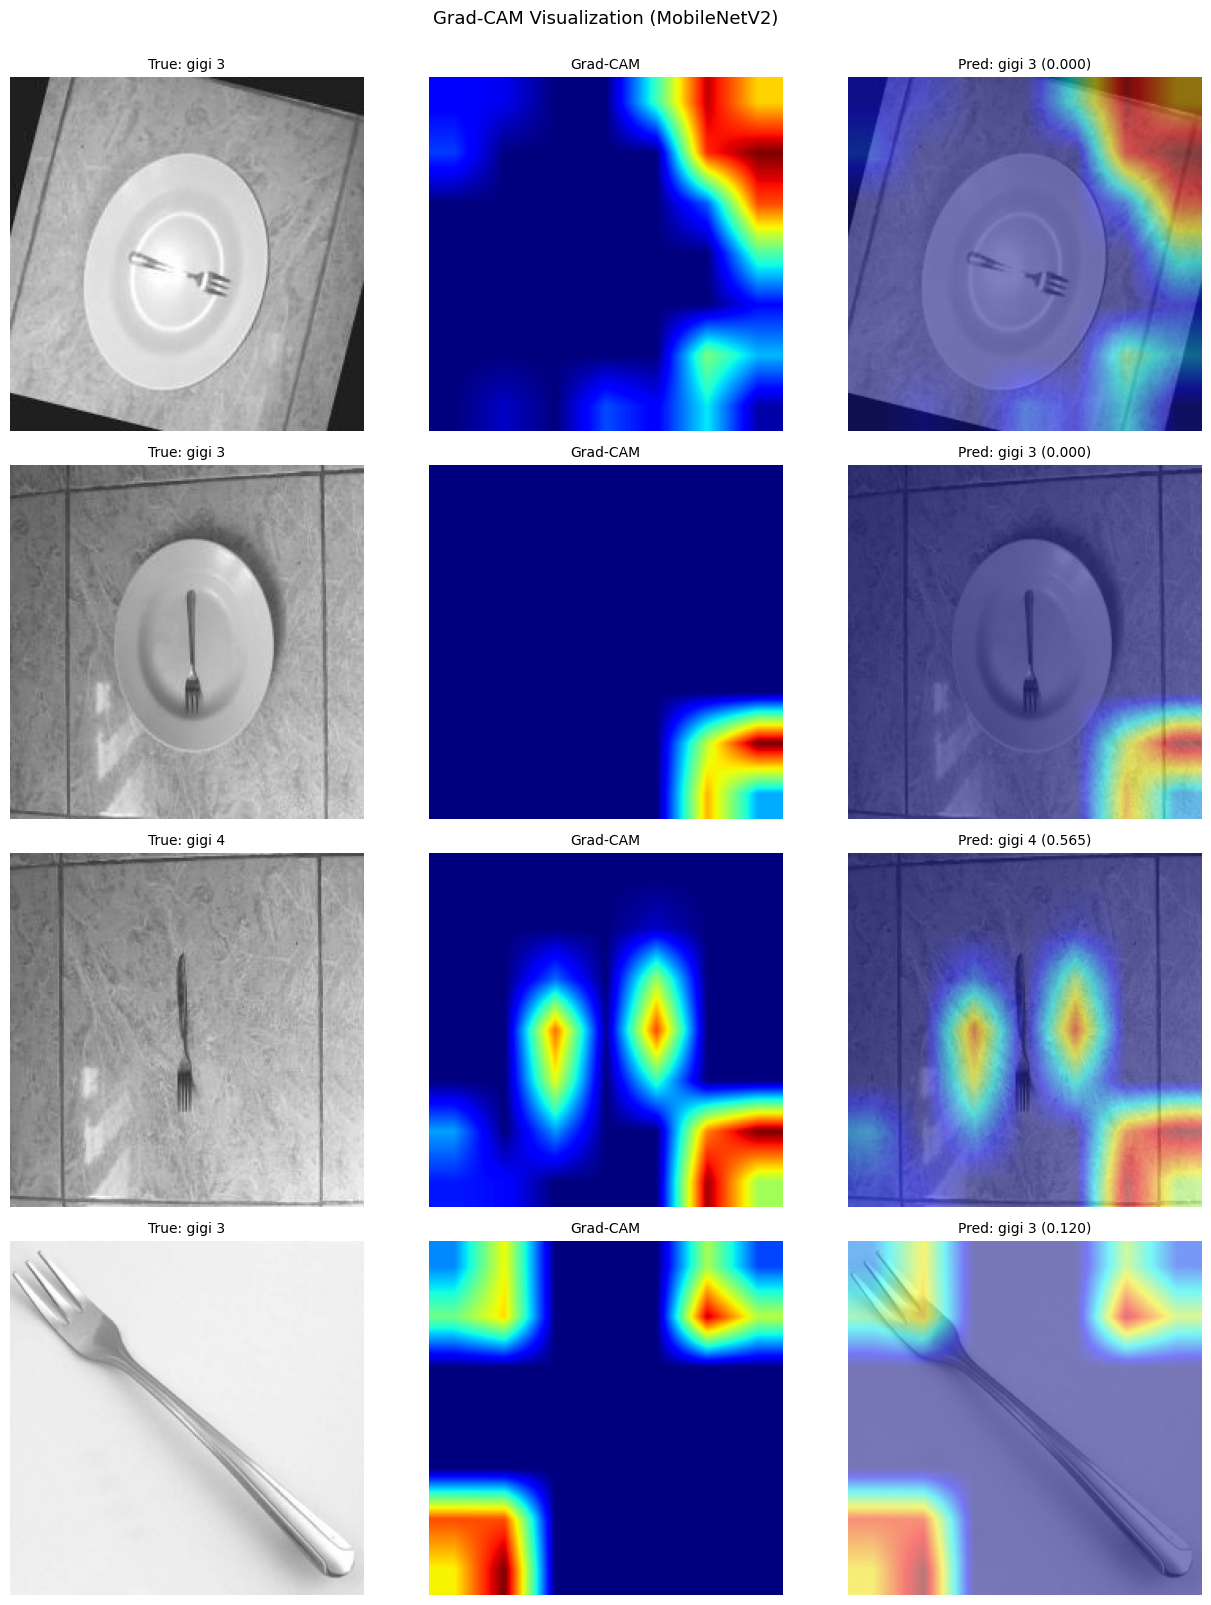

In [38]:
import cv2

def get_gradcam_heatmap(model, img_array, base_model_idx=1):
    base_model = model.layers[base_model_idx]
    
    # FIXED: pakai isinstance check (kompatibel dengan TF 2.16+)
    last_conv_layer_name = None
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    
    if last_conv_layer_name is None:
        raise ValueError("Tidak ada Conv2D layer ditemukan")
    
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_out, base_out = grad_model(img_array)
        x = base_out
        for layer in model.layers[base_model_idx+1:]:
            x = layer(x)
        pred = x[:, 0]
    
    grads = tape.gradient(pred, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, model, alpha=0.5):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_tensor = np.expand_dims(img_array, 0).astype(np.float32)
    
    heatmap = get_gradcam_heatmap(model, img_tensor)
    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = (img_array * 255 * (1 - alpha) + heatmap_colored * alpha).astype(np.uint8)
    
    prob = model.predict(img_tensor, verbose=0)[0, 0]
    pred_class = CLASS_NAMES[int(prob > 0.5)]
    return img_array, heatmap, superimposed, prob, pred_class

# Grad-CAM untuk 4 sample test
n_samples = min(4, len(test_df_aug))
sample_test = test_df_aug.sample(n_samples, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(n_samples, 3, figsize=(13, 4*n_samples))
if n_samples == 1:
    axes = axes.reshape(1, -1)

for i, row in sample_test.iterrows():
    img, hm, sup, prob, pred = display_gradcam(row["filepath"], mobilenet)
    axes[i, 0].imshow(img); axes[i, 0].set_title(f"True: {row['label_name']}", fontsize=10); axes[i, 0].axis("off")
    axes[i, 1].imshow(hm, cmap='jet'); axes[i, 1].set_title("Grad-CAM", fontsize=10); axes[i, 1].axis("off")
    axes[i, 2].imshow(sup); axes[i, 2].set_title(f"Pred: {pred} ({prob:.3f})", fontsize=10); axes[i, 2].axis("off")

plt.suptitle("Grad-CAM Visualization (MobileNetV2)", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(RESULT_DIR / "gradcam_visualizations.png", dpi=200, bbox_inches='tight')
plt.show()

=== DEMO PREDIKSI ===

True class: gigi 3


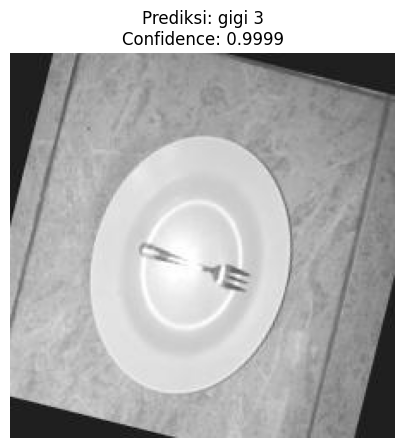

Result: {'predicted_class': 'gigi 3', 'confidence': 0.9999212026596069, 'raw_probability': 7.881510828156024e-05}

True class: gigi 3


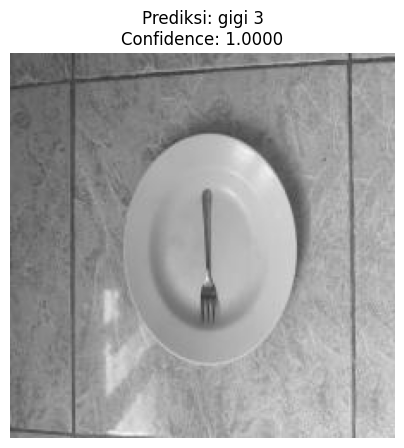

Result: {'predicted_class': 'gigi 3', 'confidence': 0.9999935030937195, 'raw_probability': 6.471980668720789e-06}

True class: gigi 4


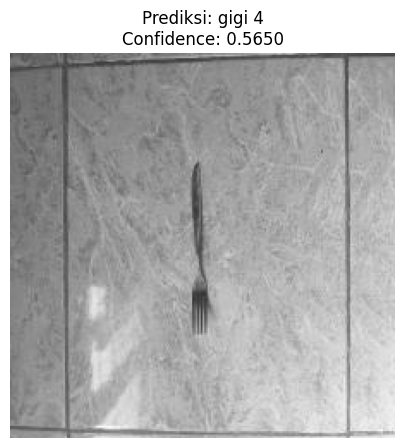

Result: {'predicted_class': 'gigi 4', 'confidence': 0.564965009689331, 'raw_probability': 0.564965009689331}



In [39]:
def predict_new_image(image_path, model=None, show=True):
    if model is None:
        model = mobilenet
    img = Image.open(image_path).convert("RGB").resize(IMG_SIZE)
    img_tensor = np.expand_dims(np.array(img) / 255.0, 0).astype(np.float32)
    prob = model.predict(img_tensor, verbose=0)[0, 0]
    pred_class = CLASS_NAMES[int(prob > 0.5)]
    confidence = prob if prob > 0.5 else 1 - prob
    if show:
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f"Prediksi: {pred_class}\nConfidence: {confidence:.4f}", fontsize=12)
        plt.axis("off")
        plt.show()
    return {"predicted_class": pred_class, "confidence": float(confidence),
            "raw_probability": float(prob)}

# Demo dengan 3 sampel test
print("=== DEMO PREDIKSI ===\n")
n_demo = min(3, len(test_df_aug))
for _, row in test_df_aug.sample(n_demo, random_state=SEED).iterrows():
    print(f"True class: {row['label_name']}")
    result = predict_new_image(row["filepath"], show=True)
    print(f"Result: {result}\n")

In [40]:
# Demo dengan gambar baru di luar dataset:
# predict_new_image(r"C:\path\ke\gambar_baru.jpg")

# Atau dengan model lain:
# predict_new_image(r"C:\path\ke\gambar.jpg", model=efficientnet)

print("Function siap pakai: predict_new_image('path/to/image.jpg')")

Function siap pakai: predict_new_image('path/to/image.jpg')


In [41]:
print("=" * 50)
print("SEMUA PROSES SELESAI!")
print("=" * 50)
print(f"\nDataset augmented : {AUG_DIR}")
print(f"Models tersimpan  : {MODEL_DIR}")
print(f"Results tersimpan : {RESULT_DIR}\n")
print("Files output:")
for f in sorted(RESULT_DIR.glob("*")):
    print(f"  - {f.name} ({f.stat().st_size/1024:.1f} KB)")

SEMUA PROSES SELESAI!

Dataset augmented : /kaggle/working/v3_workspace/augmented
Models tersimpan  : /kaggle/working/v3_workspace/saved_models
Results tersimpan : /kaggle/working/v3_workspace/results

Files output:
  - comparison_all_models.csv (0.3 KB)
  - comparison_chart.png (102.7 KB)
  - confusion_matrices_all.png (125.3 KB)
  - gradcam_visualizations.png (733.3 KB)
  - history_cnn.png (166.5 KB)
  - history_efficientnet.png (155.0 KB)
  - history_mobilenet.png (173.2 KB)


In [ ]:
# Print train vs val accuracy untuk DL models
print("=== CEK OVERFITTING ===\n")

# MobileNetV2 (Phase 2 = final fine-tuning)
print("--- MobileNetV2 (Phase 2 Fine-tuning) ---")
print(f"Train acc terakhir: {hist_mn2.history['accuracy'][-1]:.4f}")
print(f"Val acc terakhir  : {hist_mn2.history['val_accuracy'][-1]:.4f}")
gap_mn = hist_mn2.history['accuracy'][-1] - hist_mn2.history['val_accuracy'][-1]
print(f"Gap: {gap_mn:.4f} {' Overfitting' if gap_mn > 0.10 else ' Sehat'}\n")

# EfficientNetB0
print("--- EfficientNetB0 ---")
print(f"Train acc terakhir: {hist_eff.history['accuracy'][-1]:.4f}")
print(f"Val acc terakhir  : {hist_eff.history['val_accuracy'][-1]:.4f}")
gap_eff = hist_eff.history['accuracy'][-1] - hist_eff.history['val_accuracy'][-1]
print(f"Gap: {gap_eff:.4f} {' Overfitting' if gap_eff > 0.10 else ' Sehat'}\n")

# CNN Baseline
print("--- CNN Baseline ---")
print(f"Train acc terakhir: {hist_cnn.history['accuracy'][-1]:.4f}")
print(f"Val acc terakhir  : {hist_cnn.history['val_accuracy'][-1]:.4f}")
gap_cnn = hist_cnn.history['accuracy'][-1] - hist_cnn.history['val_accuracy'][-1]
print(f"Gap: {gap_cnn:.4f} {' Overfitting' if gap_cnn > 0.10 else ' Sehat'}\n")

=== CEK OVERFITTING ===

--- MobileNetV2 (Phase 2 Fine-tuning) ---
Train acc terakhir: 0.8730
Val acc terakhir  : 0.9394
Gap: -0.0664 ✅ Sehat

--- EfficientNetB0 ---
Train acc terakhir: 0.9145
Val acc terakhir  : 0.9293
Gap: -0.0148 ✅ Sehat

--- CNN Baseline ---
Train acc terakhir: 0.6055
Val acc terakhir  : 0.4646
Gap: 0.1409 ⚠️ Overfitting



In [44]:
# Cek mana yang sering salah
print("=== ANALISIS MISKLASIFIKASI MobileNetV2 ===\n")

# Cari indices yang salah klasifikasi
best_res = all_results[np.argmax([r["F1-Score"] for r in all_results])]
y_true = best_res["y_true"]
y_pred = best_res["y_pred"]

misclassified = []
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if yt != yp:
        misclassified.append({
            "idx": i,
            "true": CLASS_NAMES[yt],
            "pred": CLASS_NAMES[yp]
        })

print(f"Total misklasifikasi: {len(misclassified)} dari {len(y_true)}")
print(f"\nDistribusi error:")
g3_to_g4 = sum(1 for m in misclassified if m["true"] == "gigi 3")
g4_to_g3 = sum(1 for m in misclassified if m["true"] == "gigi 4")
print(f"  Gigi 3 → Gigi 4: {g3_to_g4}")
print(f"  Gigi 4 → Gigi 3: {g4_to_g3}")

=== ANALISIS MISKLASIFIKASI MobileNetV2 ===

Total misklasifikasi: 10 dari 100

Distribusi error:
  Gigi 3 → Gigi 4: 8
  Gigi 4 → Gigi 3: 2
